# Project 7: Fraud Detection
**Oasis Infobyte - Level 2**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Generate Imbalanced Transaction Dataset

In [2]:
np.random.seed(42)
legit = pd.DataFrame({
    'Amount': np.random.exponential(100, 4800),
    'Time_Hour': np.random.randint(6, 23, 4800),
    'Num_Transactions_Day': np.random.randint(1, 10, 4800),
    'Distance_from_Home': np.random.uniform(0, 50, 4800),
    'Foreign_Transaction': np.random.choice([0,1], 4800, p=[0.95,0.05]),
    'High_Risk_Country': np.random.choice([0,1], 4800, p=[0.98,0.02]),
    'Used_Chip': np.random.choice([0,1], 4800, p=[0.1,0.9]),
    'Used_PIN': np.random.choice([0,1], 4800, p=[0.2,0.8]),
    'Online_Order': np.random.choice([0,1], 4800, p=[0.7,0.3]),
    'Class': 0
})
fraud = pd.DataFrame({
    'Amount': np.random.exponential(500, 200),
    'Time_Hour': np.random.choice([0,1,2,3,4,5], 200),
    'Num_Transactions_Day': np.random.randint(10, 50, 200),
    'Distance_from_Home': np.random.uniform(100, 1000, 200),
    'Foreign_Transaction': np.random.choice([0,1], 200, p=[0.3,0.7]),
    'High_Risk_Country': np.random.choice([0,1], 200, p=[0.4,0.6]),
    'Used_Chip': np.random.choice([0,1], 200, p=[0.8,0.2]),
    'Used_PIN': np.random.choice([0,1], 200, p=[0.9,0.1]),
    'Online_Order': np.random.choice([0,1], 200, p=[0.2,0.8]),
    'Class': 1
})
df = pd.concat([legit, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)
print('Shape:', df.shape)
print('Fraud rate:', df['Class'].mean()*100, '%')
df['Class'].value_counts()

Shape: (5000, 10)
Fraud rate: 4.0 %


,count
Class,
0,4800
1,200


## Step 2: Visualize Class Imbalance

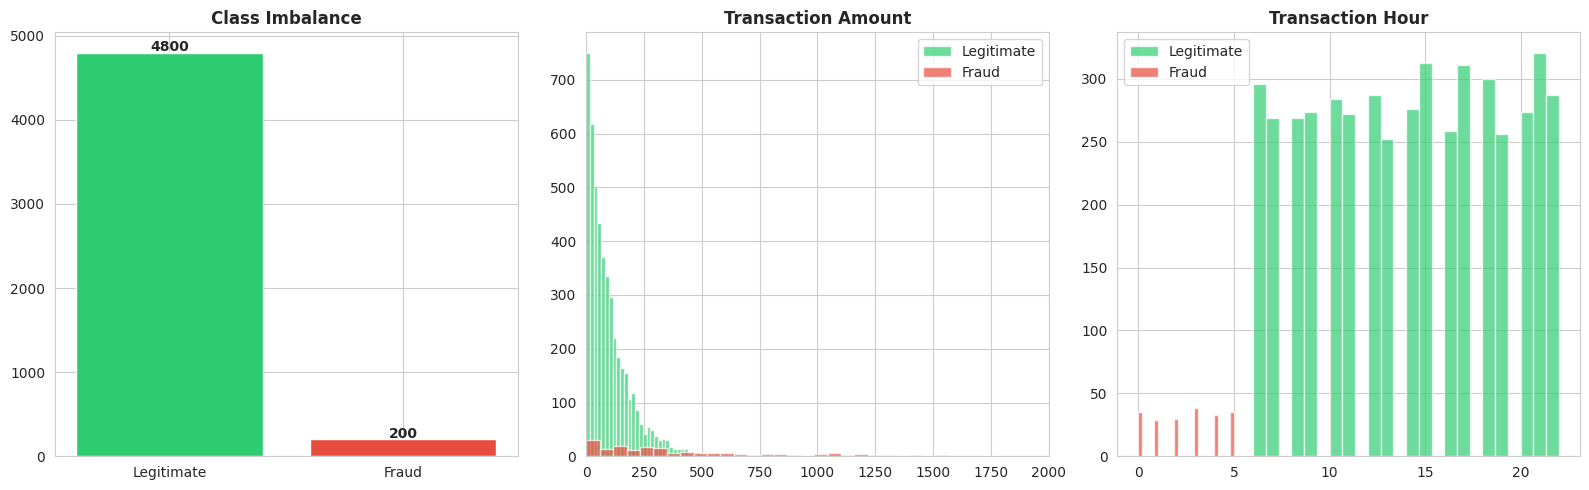

In [3]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate','Fraud'], class_counts.values, color=['#2ECC71','#E74C3C'])
axes[0].set_title('Class Imbalance', fontweight='bold')
for i,v in enumerate(class_counts.values): axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, color='#2ECC71', label='Legitimate')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, color='#E74C3C', label='Fraud')
axes[1].set_title('Transaction Amount', fontweight='bold'); axes[1].legend(); axes[1].set_xlim(0,2000)

axes[2].hist(df[df['Class']==0]['Time_Hour'], bins=24, alpha=0.7, color='#2ECC71', label='Legitimate')
axes[2].hist(df[df['Class']==1]['Time_Hour'], bins=24, alpha=0.7, color='#E74C3C', label='Fraud')
axes[2].set_title('Transaction Hour', fontweight='bold'); axes[2].legend()
plt.tight_layout(); plt.show()

## Step 3: Train Models with Class Balancing

In [4]:
feature_cols = ['Amount','Time_Hour','Num_Transactions_Day','Distance_from_Home',
                'Foreign_Transaction','High_Risk_Country','Used_Chip','Used_PIN','Online_Order']
X = df[feature_cols]; y = df['Class']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train); X_te = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}
results = {}
for name, model in models.items():
    model.fit(X_tr, y_train); preds = model.predict(X_te)
    results[name] = {
        'preds':preds,
        'accuracy': accuracy_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }
    print(f"{name}: Acc={results[name]['accuracy']:.3f} | Recall={results[name]['recall']:.3f} | F1={results[name]['f1']:.3f}")

Logistic Regression: Acc=1.000 | Recall=1.000 | F1=1.000
Decision Tree: Acc=1.000 | Recall=1.000 | F1=1.000
Random Forest: Acc=1.000 | Recall=1.000 | F1=1.000


## Step 4: Best Model Evaluation

Best Model: Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       960
       Fraud       1.00      1.00      1.00        40

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



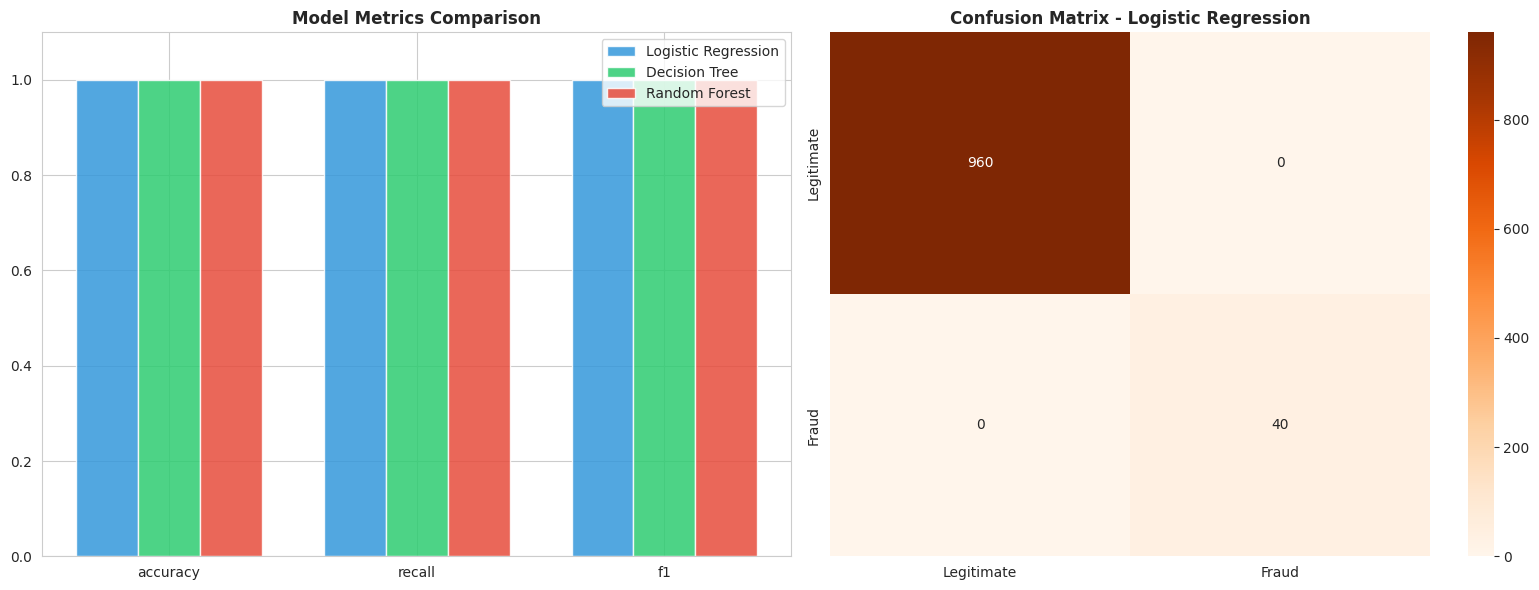

In [5]:
best = max(results, key=lambda x: results[x]['f1'])
print(f'Best Model: {best}')
print(classification_report(y_test, results[best]['preds'], target_names=['Legitimate','Fraud']))

fig, axes = plt.subplots(1,2,figsize=(16,6))
metrics = ['accuracy','recall','f1']
x = np.arange(len(metrics)); width = 0.25
c = ['#3498DB','#2ECC71','#E74C3C']
for i,(name,res) in enumerate(results.items()):
    axes[0].bar(x+i*width, [res[m] for m in metrics], width, label=name, color=c[i], alpha=0.85)
axes[0].set_xticks(x+width); axes[0].set_xticklabels(metrics)
axes[0].set_title('Model Metrics Comparison', fontweight='bold')
axes[0].set_ylim(0,1.1); axes[0].legend()

cm = confusion_matrix(y_test, results[best]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
axes[1].set_title(f'Confusion Matrix - {best}', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 5: Feature Importance

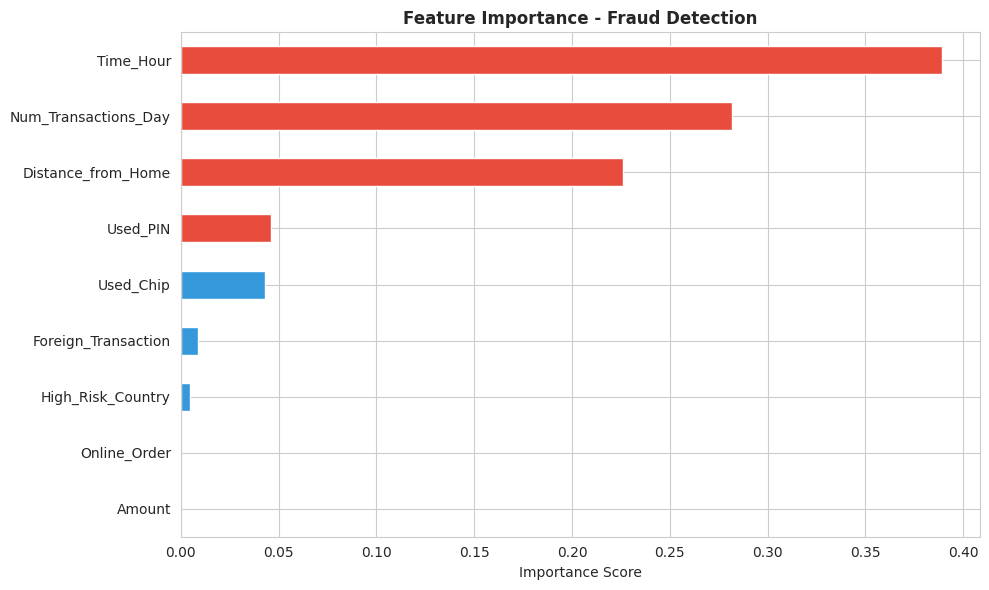

Top fraud indicators:
Distance_from_Home      0.226106
Num_Transactions_Day    0.281552
Time_Hour               0.389078
dtype: float64


In [6]:
rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(10,6))
imp.plot(kind='barh', color=['#E74C3C' if v>imp.median() else '#3498DB' for v in imp])
plt.title('Feature Importance - Fraud Detection', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()
print('Top fraud indicators:')
print(imp.tail(3))